In [1]:
!pip install pandas matplotlib seaborn


[notice] A new release of pip available: 22.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install psycopg2

  Using cached psycopg2-2.9.10.tar.gz (385 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for psycopg2
Failed to build psycopg2
  Running setup.py install for psycopg2: started
  Running setup.py install for psycopg2: finished with status 'error'

[notice] A new release of pip available: 22.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  python setup.py bdist_wheel did not run successfully.
  exit code: 1
  
  [20 lines of output]
  running bdist_wheel
  running build
  running build_py
  creating build
  creating build\lib.win-amd64-3.8
  creating build\lib.win-amd64-3.8\psycopg2
  copying lib\errorcodes.py -> build\lib.win-amd64-3.8\psycopg2
  copying lib\errors.py -> build\lib.win-amd64-3.8\psycopg2
  copying lib\extensions.py -> build\lib.win-amd64-3.8\psycopg2
  copying lib\extras.py -> build\lib.win-amd64-3.8\psycopg2
  copying lib\pool.py -> build\lib.win-amd64-3.8\psycopg2
  copying lib\sql.py -> build\lib.win-amd64-3.8\psycopg2
  copying lib\tz.py -> build\lib.win-amd64-3.8\psycopg2
  copying lib\_ipaddress.py -> build\lib.win-amd64-3.8\psycopg2
  copying lib\_json.py -> build\lib.win-amd64-3.8\psycopg2
  copying lib\_range.py -> build\lib.win-amd64-3.8\psycopg2
  copying lib\__init__.py -> build\lib.win-amd64-3.8\psycopg2
  running build_ext
  building 'psycopg2._psy

In [3]:
pip install prophet


[notice] A new release of pip available: 22.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Load The CSV

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV from Desktop
df = pd.read_csv(r'C:\Users\simim\Downloads\hse_waiting_list.csv')

print(f'Total rows: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Total rows: 1944
Columns: ['archive_date', 'adult_child', 'hospital_name', 'wait_0_6_months', 'wait_6_12_months', 'wait_12_18_months', 'wait_18_plus_months', 'total']


,archive_date,adult_child,hospital_name,wait_0_6_months,wait_6_12_months,wait_12_18_months,wait_18_plus_months,total
0,2024-01-25,Adult,Bantry General Hospital,626,218,63,37,944
1,2024-01-25,Adult,Beaumont Hospital,24513,9977,910,98,35497
2,2024-01-25,Adult,Cavan General Hospital,5588,1652,22,18,7279
3,2024-01-25,Adult,Connolly Hospital Blanchardstown,4498,239,0,0,4737
4,2024-01-25,Adult,Coombe Women and Infants University Hospital,1370,922,285,60,2636


check our Datatype

In [24]:
# Check shape
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print()

# Check column names
print('Column names:')
print(df.columns.tolist())
print()

# Check data types
print('Data types:')
print(df.dtypes)

Rows: 1944
Columns: 8

Column names:
['archive_date', 'adult_child', 'hospital_name', 'wait_0_6_months', 'wait_6_12_months', 'wait_12_18_months', 'wait_18_plus_months', 'total']

Data types:
archive_date           object
adult_child            object
hospital_name          object
wait_0_6_months         int64
wait_6_12_months        int64
wait_12_18_months       int64
wait_18_plus_months     int64
total                   int64
dtype: object


In [5]:
# Convert archive_date to proper date format
df['archive_date'] = pd.to_datetime(df['archive_date'])

# Extract year and month for analysis
df['year']  = df['archive_date'].dt.year
df['month'] = df['archive_date'].dt.month

print('Date column fixed! ✅')
print(f'Date range: {df.archive_date.min()} to {df.archive_date.max()}')

Date column fixed! ✅
Date range: 2024-01-25 00:00:00 to 2026-01-29 00:00:00


In [6]:
print('=== NATIONAL WAITING LIST SUMMARY ===')
print()
print(f"Total patient records:     {df['total'].sum():,}")
print(f"Unique hospitals:          {df['hospital_name'].nunique()}")
print(f"Unique months:             {df['archive_date'].nunique()}")
print(f"Date range:                {df['archive_date'].min().date()} to {df['archive_date'].max().date()}")
print()
print(f"Average monthly total:     {df.groupby('archive_date')['total'].sum().mean():,.0f}")
print(f"Max monthly total:         {df.groupby('archive_date')['total'].sum().max():,.0f}")
print(f"Min monthly total:         {df.groupby('archive_date')['total'].sum().min():,.0f}")

=== NATIONAL WAITING LIST SUMMARY ===

Total patient records:     14,883,689
Unique hospitals:          44
Unique months:             25
Date range:                2024-01-25 to 2026-01-29

Average monthly total:     595,348
Max monthly total:         631,608
Min monthly total:         556,248


In [7]:
# Normalize all dates to 1st of each month
df['archive_date'] = df['archive_date'].dt.to_period('M').dt.to_timestamp()

print('Dates normalized! ✅')
print(df['archive_date'].unique())

Dates normalized! ✅
<DatetimeArray>
['2024-01-01 00:00:00', '2024-02-01 00:00:00', '2024-03-01 00:00:00',
 '2024-04-01 00:00:00', '2024-05-01 00:00:00', '2024-06-01 00:00:00',
 '2024-07-01 00:00:00', '2024-08-01 00:00:00', '2024-09-01 00:00:00',
 '2024-10-01 00:00:00', '2024-11-01 00:00:00', '2024-12-01 00:00:00',
 '2025-01-01 00:00:00', '2025-02-01 00:00:00', '2025-03-01 00:00:00',
 '2025-04-01 00:00:00', '2025-05-01 00:00:00', '2025-06-01 00:00:00',
 '2025-07-01 00:00:00', '2025-08-01 00:00:00', '2025-09-01 00:00:00',
 '2025-10-01 00:00:00', '2025-11-01 00:00:00', '2025-12-01 00:00:00',
 '2026-01-01 00:00:00']
Length: 25, dtype: datetime64[ns]


In [8]:
# Check what's happening with critical waiting by month
monthly_check = df.groupby('archive_date').agg(
    total_waiting    = ('total', 'sum'),
    critical_waiting = ('wait_18_plus_months', 'sum')
).reset_index()

print(monthly_check.to_string())

   archive_date  total_waiting  critical_waiting
0    2024-01-01         568691             54804
1    2024-02-01         578595             54668
2    2024-03-01         585030             54292
3    2024-04-01         589225             53850
4    2024-05-01         593388             52727
5    2024-06-01         597948             52342
6    2024-07-01         599458             50505
7    2024-08-01         601490             50276
8    2024-09-01         595575             49328
9    2024-10-01         588544             48516
10   2024-11-01         572403             45883
11   2024-12-01         556248             42996
12   2025-01-01         569249             43908
13   2025-02-01         575716             44268
14   2025-03-01         581736             44334
15   2025-04-01         584713             44984
16   2025-05-01         586917             44442
17   2025-06-01         600390             44489
18   2025-07-01         614470             43599
19   2025-08-01     

In [10]:
NAVY  = '#003F5C'
RED   = '#FF6361'
GREEN = '#2ECC71'
AMBER = '#FFA600'

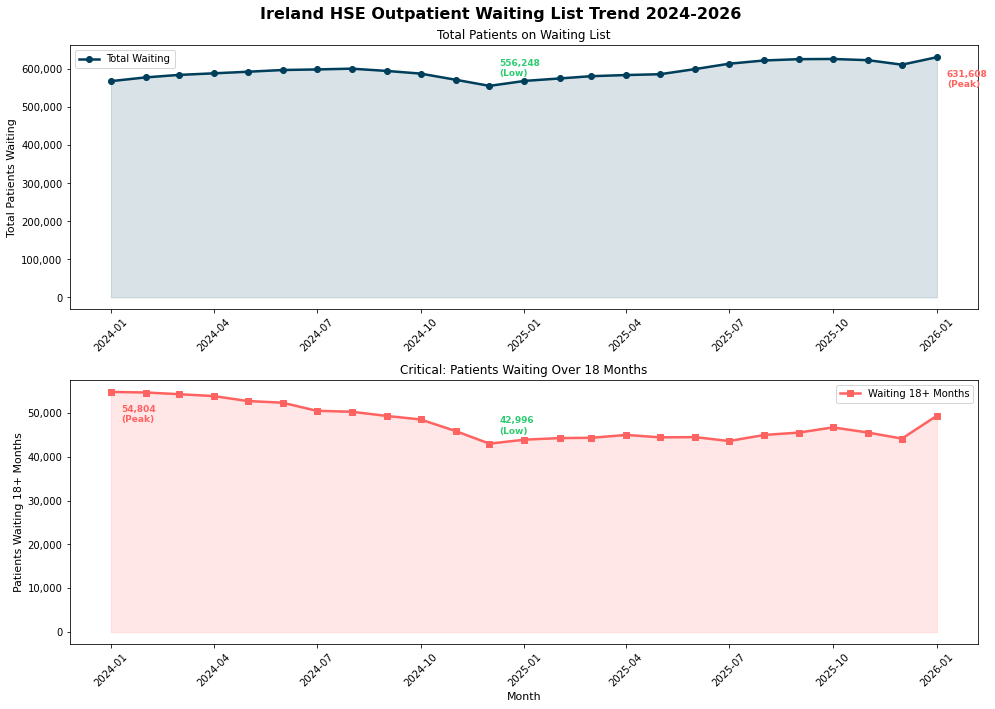

Chart 1 saved! ✅


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Ireland HSE Outpatient Waiting List Trend 2024-2026',
             fontsize=16, fontweight='bold')

dates            = monthly_check['archive_date'].values
total_waiting    = monthly_check['total_waiting'].values
critical_waiting = monthly_check['critical_waiting'].values

# ── Top Chart — Total Waiting ─────────────────────────────────
ax1.plot(dates, total_waiting,
         color=NAVY, linewidth=2.5, marker='o', markersize=6,
         label='Total Waiting')
ax1.fill_between(dates, total_waiting, alpha=0.15, color=NAVY)
ax1.set_ylabel('Total Patients Waiting', fontsize=11)
ax1.set_title('Total Patients on Waiting List', fontsize=12)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax1.legend(fontsize=10)

# Add value labels on key points
ax1.annotate(f'{total_waiting.max():,.0f}\n(Peak)',
             xy=(dates[total_waiting.argmax()], total_waiting.max()),
             xytext=(10, -30), textcoords='offset points',
             color=RED, fontweight='bold', fontsize=9)

ax1.annotate(f'{total_waiting.min():,.0f}\n(Low)',
             xy=(dates[total_waiting.argmin()], total_waiting.min()),
             xytext=(10, 10), textcoords='offset points',
             color=GREEN, fontweight='bold', fontsize=9)

# ── Bottom Chart — Critical 18 Month+ Waiting ─────────────────
ax2.plot(dates, critical_waiting,
         color=RED, linewidth=2.5, marker='s', markersize=6,
         label='Waiting 18+ Months')
ax2.fill_between(dates, critical_waiting, alpha=0.15, color=RED)
ax2.set_ylabel('Patients Waiting 18+ Months', fontsize=11)
ax2.set_title('Critical: Patients Waiting Over 18 Months', fontsize=12)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax2.legend(fontsize=10)
ax2.set_xlabel('Month', fontsize=11)

# Add value labels on key points
ax2.annotate(f'{critical_waiting.max():,.0f}\n(Peak)',
             xy=(dates[critical_waiting.argmax()], critical_waiting.max()),
             xytext=(10, -30), textcoords='offset points',
             color=RED, fontweight='bold', fontsize=9)

ax2.annotate(f'{critical_waiting.min():,.0f}\n(Low)',
             xy=(dates[critical_waiting.argmin()], critical_waiting.min()),
             xytext=(10, 10), textcoords='offset points',
             color=GREEN, fontweight='bold', fontsize=9)

# Formatting both charts
for ax in [ax1, ax2]:
    plt.sca(ax)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('chart1_national_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved! ✅')


"Ireland reduced its most critical waiting list patients by 21% during 2024 but lost all that progress in 2025 — ending January 2026 at the worst total ever recorded."

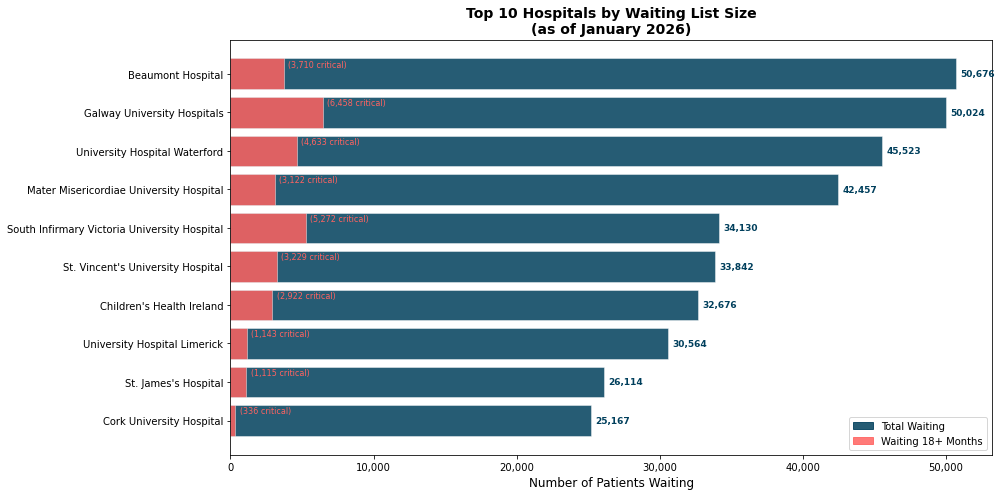

Chart 2 saved! ✅


In [12]:
# Get latest month data only
latest_date = df['archive_date'].max()
latest_df   = df[df['archive_date'] == latest_date]

# Group by hospital - combine Adult and Child
hospital_totals = latest_df.groupby('hospital_name').agg(
    total_waiting    = ('total', 'sum'),
    critical_waiting = ('wait_18_plus_months', 'sum')
).reset_index()

# Sort and get top 10
top10 = hospital_totals.nlargest(10, 'total_waiting').reset_index(drop=True)

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    top10['hospital_name'].values,
    top10['total_waiting'].values,
    color=NAVY, alpha=0.85, edgecolor='white', linewidth=0.5
)

# Add critical waiting as overlay bars
ax.barh(
    top10['hospital_name'].values,
    top10['critical_waiting'].values,
    color=RED, alpha=0.85, edgecolor='white', linewidth=0.5,
    label='Waiting 18+ Months'
)

# Add value labels on each bar
for i, (total, critical) in enumerate(zip(
        top10['total_waiting'].values,
        top10['critical_waiting'].values)):
    ax.text(total + 300, i, f'{total:,}',
            va='center', fontsize=9, fontweight='bold', color=NAVY)
    ax.text(critical + 300, i - 0.25, f'({critical:,} critical)',
            va='center', fontsize=8, color=RED)

# Formatting
ax.set_xlabel('Number of Patients Waiting', fontsize=12)
ax.set_title(f'Top 10 Hospitals by Waiting List Size\n(as of {latest_date.strftime("%B %Y")})',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Legend
navy_patch = plt.Rectangle((0,0),1,1, color=NAVY, alpha=0.85)
red_patch  = plt.Rectangle((0,0),1,1, color=RED,  alpha=0.85)
ax.legend([navy_patch, red_patch],
          ['Total Waiting', 'Waiting 18+ Months'],
          fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('chart2_top10_hospitals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved! ✅')

Beaumont and Galway are the biggest by volume — both over 50,000 patients waiting.
But look at Galway vs Beaumont — Galway has 6,458 critical patients vs Beaumont's 3,710. So Galway is actually in a worse crisis despite similar total numbers.
South Infirmary Victoria stands out — 5,272 critical patients from only 34,130 total. That's 15% critical rate — much worse than bigger hospitals.
Cork University Hospital — only 336 critical patients from 25,167 total — best performing large hospital in Ireland. Just 1.3% critical rate.

Chart 3 — Hidden Crisis HospitalsThe hospitals that look small but are catastrophically failing their patients

C:\Users\simim\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 128308 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\simim\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 128992 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\simim\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 128993 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\simim\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 128994 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\simim\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 128308 missing from current font.
  font.set_text(s, 0, flags=flags)
C:\Users\simim\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 128992 missing fr

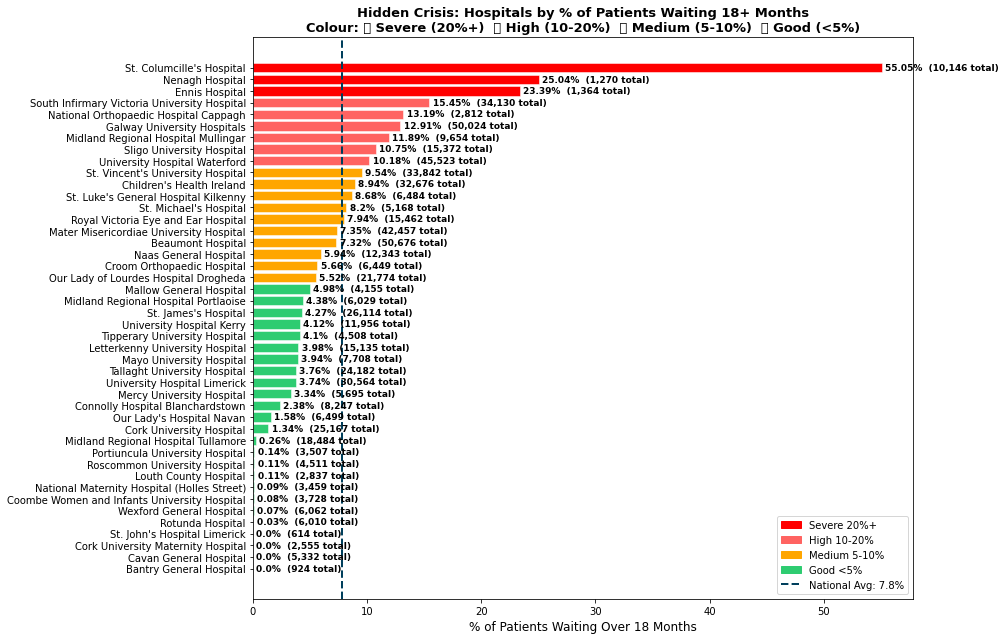

Chart 3 saved! ✅


In [13]:
# Get latest month data
latest_df = df[df['archive_date'] == latest_date]

# Group by hospital
hospital_crisis = latest_df.groupby('hospital_name').agg(
    total_waiting    = ('total', 'sum'),
    critical_waiting = ('wait_18_plus_months', 'sum')
).reset_index()

# Calculate critical percentage
hospital_crisis['critical_pct'] = (
    hospital_crisis['critical_waiting'] * 100.0 /
    hospital_crisis['total_waiting']
).round(2)

# Filter hospitals with at least 500 patients (remove tiny ones)
hospital_crisis = hospital_crisis[
    hospital_crisis['total_waiting'] >= 500
].sort_values('critical_pct', ascending=False).reset_index(drop=True)

# Colour bars by severity
def get_color(pct):
    if pct >= 20:   return '#FF0000'   # Severe — bright red
    elif pct >= 10: return '#FF6361'   # High — red
    elif pct >= 5:  return '#FFA600'   # Medium — amber
    else:           return '#2ECC71'   # Good — green

colors = [get_color(p) for p in hospital_crisis['critical_pct'].values]

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 9))

bars = ax.barh(
    hospital_crisis['hospital_name'].values,
    hospital_crisis['critical_pct'].values,
    color=colors, edgecolor='white', linewidth=0.5
)

# Add percentage labels
for i, (pct, total) in enumerate(zip(
        hospital_crisis['critical_pct'].values,
        hospital_crisis['total_waiting'].values)):
    ax.text(pct + 0.3, i,
            f'{pct}%  ({total:,} total)',
            va='center', fontsize=9, fontweight='bold')

# Reference line — national average
national_avg = (
    hospital_crisis['critical_waiting'].sum() /
    hospital_crisis['total_waiting'].sum() * 100
)
ax.axvline(national_avg, color=NAVY, linestyle='--',
           linewidth=2, label=f'National Average: {national_avg:.1f}%')

# Formatting
ax.set_xlabel('% of Patients Waiting Over 18 Months', fontsize=12)
ax.set_title('Hidden Crisis: Hospitals by % of Patients Waiting 18+ Months\n'
             'Colour: 🔴 Severe (20%+)  🟠 High (10-20%)  🟡 Medium (5-10%)  🟢 Good (<5%)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()

# Legend
import matplotlib.patches as mpatches
patches = [
    mpatches.Patch(color='#FF0000', label='Severe 20%+'),
    mpatches.Patch(color='#FF6361', label='High 10-20%'),
    mpatches.Patch(color='#FFA600', label='Medium 5-10%'),
    mpatches.Patch(color='#2ECC71', label='Good <5%'),
]
ax.legend(handles=patches + [
    plt.Line2D([0],[0], color=NAVY, linestyle='--', linewidth=2,
               label=f'National Avg: {national_avg:.1f}%')
], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('chart3_hidden_crisis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved! ✅')

What This Chart Is Screaming
🔴 Severe Crisis (Red):

St. Columcille's Hospital — 55% — over half their patients waiting 18+ months. This is extraordinary and should be front page news
Nenagh — 25% — 1 in 4 patients
Ennis — 23% — nearly 1 in 4 patients

🟠 High (Amber/Red):

South Infirmary Victoria — 15.45%
National Orthopaedic Cappagh — 13.19%
Galway — 12.91% — despite being one of Ireland's biggest hospitals

🟢 Best Performing (Green):

Bantry, Cavan, Cork Maternity — 0% critical patients
Rotunda — 0.03% — virtually zero crisis patients

The national average dashed line at 7.8% makes it instantly clear which hospitals are failing vs performing.

In [14]:
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Prophet requires exactly 2 columns named 'ds' and 'y'
# ds = date, y = value to forecast
prophet_df = monthly_check[['archive_date', 'total_waiting']].copy()
prophet_df.columns = ['ds', 'y']

print('Data prepared for Prophet! ✅')
print(prophet_df)

Data prepared for Prophet! ✅
           ds       y
0  2024-01-01  568691
1  2024-02-01  578595
2  2024-03-01  585030
3  2024-04-01  589225
4  2024-05-01  593388
5  2024-06-01  597948
6  2024-07-01  599458
7  2024-08-01  601490
8  2024-09-01  595575
9  2024-10-01  588544
10 2024-11-01  572403
11 2024-12-01  556248
12 2025-01-01  569249
13 2025-02-01  575716
14 2025-03-01  581736
15 2025-04-01  584713
16 2025-05-01  586917
17 2025-06-01  600390
18 2025-07-01  614470
19 2025-08-01  623008
20 2025-09-01  626521
21 2025-10-01  626960
22 2025-11-01  623819
23 2025-12-01  611987
24 2026-01-01  631608


In [15]:
!pip install scikit-learn


[notice] A new release of pip available: 22.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
forecast_df = monthly_check.copy()
forecast_df['month_num'] = range(len(forecast_df))

# Train model
X = forecast_df['month_num'].values.reshape(-1, 1)
y = forecast_df['total_waiting'].values

model = LinearRegression()
model.fit(X, y)

# Predict next 6 months
future_months     = np.array(range(len(forecast_df), len(forecast_df) + 6)).reshape(-1, 1)
future_dates      = pd.date_range(start='2026-02-01', periods=6, freq='MS')
future_prediction = model.predict(future_months)

print('Model trained! ✅')
print(f'Monthly growth rate: {model.coef_[0]:,.0f} patients per month')
print()
print('=== 6 MONTH FORECAST ===')
for date, pred in zip(future_dates, future_prediction):
    print(f'{date.strftime("%B %Y")}: {pred:,.0f} patients')

Model trained! ✅
Monthly growth rate: 1,821 patients per month

=== 6 MONTH FORECAST ===
February 2026: 619,016 patients
March 2026: 620,837 patients
April 2026: 622,658 patients
May 2026: 624,478 patients
June 2026: 626,299 patients
July 2026: 628,120 patients


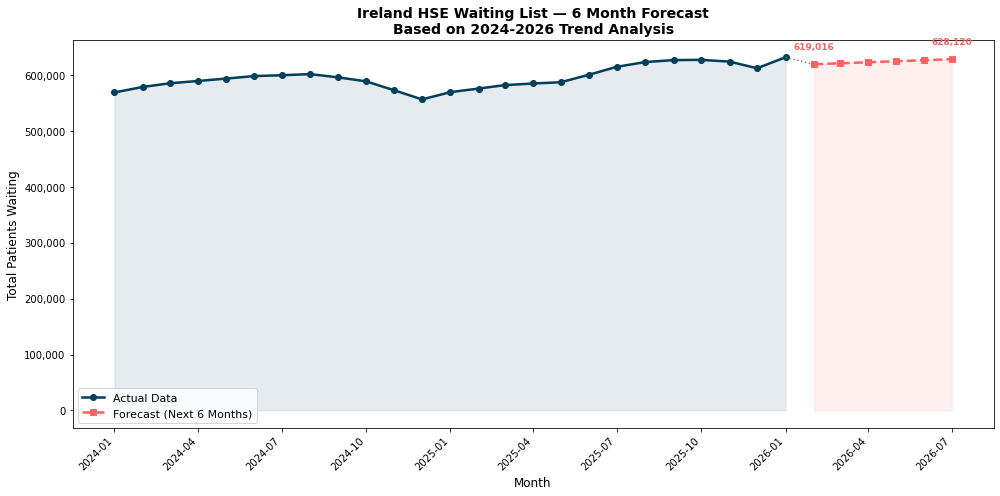

Chart 4 saved! ✅


In [17]:
fig, ax = plt.subplots(figsize=(14, 7))

hist_dates       = forecast_df['archive_date'].values
hist_vals        = forecast_df['total_waiting'].values
future_dates_arr = future_dates.to_pydatetime()
future_pred_arr  = future_prediction

# Plot historical
ax.plot(hist_dates, hist_vals,
        color=NAVY, linewidth=2.5, marker='o',
        markersize=6, label='Actual Data')
ax.fill_between(hist_dates, hist_vals, alpha=0.1, color=NAVY)

# Plot forecast
ax.plot(future_dates_arr, future_pred_arr,
        color=RED, linewidth=2.5, marker='s',
        markersize=6, linestyle='--', label='Forecast (Next 6 Months)')
ax.fill_between(future_dates_arr, future_pred_arr, alpha=0.1, color=RED)

# Connect lines
ax.plot([hist_dates[-1], future_dates_arr[0]],
        [hist_vals[-1], future_pred_arr[0]],
        color='gray', linestyle=':', linewidth=1.5)

# Only label first and last forecast point
for i, (date, pred) in enumerate(zip(future_dates_arr, future_pred_arr)):
    if i == 0 or i == len(future_pred_arr) - 1:
        ax.annotate(f'{pred:,.0f}',
                    xy=(date, pred),
                    xytext=(0, 15), textcoords='offset points',
                    ha='center', fontsize=9,
                    color=RED, fontweight='bold')

# Formatting
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Patients Waiting', fontsize=12)
ax.set_title('Ireland HSE Waiting List — 6 Month Forecast\n'
             'Based on 2024-2026 Trend Analysis',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend(fontsize=11)

fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.savefig('chart4_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved! ✅')

Navy line (Actual Data)

Clear dip in Dec 2024 to 556,248
Strong rise through 2025
Peak at 631,608 in Jan 2026

Red dashed line (Forecast):

Starts at 619,016 in February 2026
Grows steadily to 628,120 by July 2026
Shows the crisis continuing to worsen

In [18]:
# Export 1 — Full cleaned dataset
df.to_csv(r'C:\Users\simim\Desktop\hse_powerbi.csv', index=False)

# Export 2 — Monthly national totals
monthly_check.to_csv(r'C:\Users\simim\Desktop\hse_monthly_totals.csv', index=False)

# Export 3 — Hospital latest month analysis
hospital_crisis.to_csv(r'C:\Users\simim\Desktop\hse_hospital_crisis.csv', index=False)

# Export 4 — Forecast data
forecast_export = pd.DataFrame({
    'date':       future_dates,
    'forecast':   future_prediction,
    'type':       'Forecast'
})
actual_export = pd.DataFrame({
    'date':       monthly_check['archive_date'],
    'forecast':   monthly_check['total_waiting'],
    'type':       'Actual'
})
combined_forecast = pd.concat([actual_export, forecast_export])
combined_forecast.to_csv(r'C:\Users\simim\Desktop\hse_forecast.csv', index=False)

print('All 4 files exported to Desktop! ✅')

All 4 files exported to Desktop! ✅
